In [2]:
import pandas as pd
import os

In [10]:
base_df = pd.read_csv('../data/data_final_with_aadt_and_vulnerability.csv')

base_subset = base_df[['id', 'avg_truck_AADT','lat', 'lon']]
scenario_results = {}

all_dfs = []

for i in range(12):
    file_path = f'../experiment/final_delays_scenario{i}.csv'
    raw_scenario_df = pd.read_csv(file_path)

    melted_df = raw_scenario_df.melt(id_vars=['BridgeID'], var_name='Seed', value_name='Delay')

    melted_df = melted_df.dropna(subset=['Delay'])

    scenario_avg = melted_df.groupby('BridgeID')['Delay'].mean().reset_index()

    merged_df = pd.merge(
        scenario_avg,
        base_subset,
        left_on='BridgeID',
        right_on='id'
    ).drop(columns=['BridgeID'])

    #calculate impact
    merged_df['Total_Delay'] = merged_df['Delay']
    merged_df['impact_raw'] = merged_df['Total_Delay'] * merged_df['avg_truck_AADT']
    merged_df['scenario_id'] = i

    all_dfs.append(merged_df[['id', 'Total_Delay', 'avg_truck_AADT', 'lat', 'lon', 'impact_raw', 'scenario_id']])

#calculate global min and max through all scenarios
combined_data = pd.concat(all_dfs)
global_min = combined_data['impact_raw'].min()
global_max = combined_data['impact_raw'].max()

#scale the impact
for i, df in enumerate(all_dfs):
    df['impact_scaled'] = (df['impact_raw'] - global_min) / (global_max - global_min)

    scenario_results[f'scenario_{i}'] = df
    globals()[f'df_{i}'] = df


In [11]:
df_0.head()

,id,Total_Delay,avg_truck_AADT,lat,lon,impact_raw,scenario_id,impact_scaled
0,100003,47085.282230,2789.666667,23.698739,90.458861,1.313522e+08,0,0.202527
1,100007,121775.114594,1479.666667,23.705060,90.523214,1.801866e+08,0,0.277998
2,100009,13546.271862,2872.333333,23.696400,90.535099,3.890941e+07,0,0.059661
3,100011,13909.385527,2872.333333,23.694391,90.537574,3.995239e+07,0,0.061273
4,100013,13276.886634,2872.333333,23.694302,90.537707,3.813564e+07,0,0.058465


In [12]:
#aantal rijen die je hebt is aantal bruggen die kapot zijn gegaan
count_bridges = len(base_df[base_df['model_type'] == 'bridge'])

print(f"Amount bridges: {count_bridges}")

Amount bridges: 1434


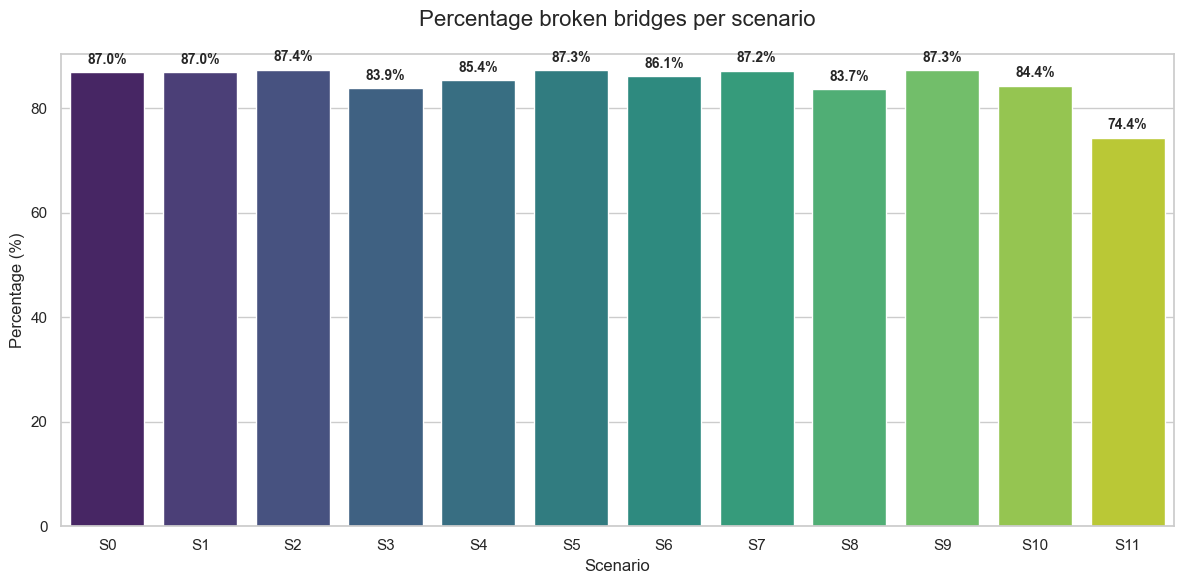

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

scenarios = [df_0, df_1, df_2, df_3, df_4, df_5, df_6, df_7, df_8, df_9, df_10, df_11]

# Bereken percentages en maak labels
percentages = [(len(df) / count_bridges) * 100 for df in scenarios]
labels = [f"S{i}" for i in range(len(scenarios))]

# Maak een DataFrame die Seaborn begrijpt
plot_df = pd.DataFrame({
    'Scenario': labels,
    'Percentage': percentages
})

# 2. Plotten
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Maak de bar chart
ax = sns.barplot(x='Scenario', y='Percentage', data=plot_df, palette='viridis', hue='Scenario', legend=False)

# 3. Styling en labels
plt.title('Percentage broken bridges per scenario', fontsize=16, pad=20)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Scenario', fontsize=12)
plt.ylim(0, max(percentages) + 3) # Extra ruimte bovenin voor de tekst

# Voeg de tekstlabels (de cijfers) boven de balken toe
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()

plt.savefig('../img/percentage_broken_bridges.png', dpi=300, bbox_inches='tight')

plt.show()

In [14]:
combined_df = pd.concat(scenarios)

avg_impact_per_bridge = combined_df.groupby('id').agg({
    'impact_scaled': 'mean',
    'impact_raw': 'mean',
    'avg_truck_AADT': 'first',
    'lat': 'first',
    'lon': 'first',
    'scenario_id': lambda x: list(x)
}).rename(columns={'scenario_id': 'scenarios_found'})

avg_impact_per_bridge['occurrence_count'] = avg_impact_per_bridge['scenarios_found'].apply(len)

avg_impact_per_bridge = avg_impact_per_bridge.sort_values(by='impact_scaled', ascending=False)

print("Top 20 most critical bridges:")

avg_impact_per_bridge[['impact_scaled', 'occurrence_count', 'scenarios_found']].head(20)

Top 20 most critical bridges:


,impact_scaled,occurrence_count,scenarios_found
id,,,
100083,0.879217,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100047,0.829622,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100051,0.783681,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
101484,0.647530,11,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
100031,0.442117,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100075,0.422411,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100049,0.401661,11,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
100043,0.397597,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100059,0.371042,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"


In [24]:
avg_impact_per_bridge[['impact_scaled', 'occurrence_count', 'scenarios_found']].tail(20)

,impact_scaled,occurrence_count,scenarios_found
id,,,
100783,0.001866,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100805,0.001861,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100819,0.001861,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100785,0.001794,11,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
100773,0.001742,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
102576,0.001498,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
101713,0.001032,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
101705,0.001027,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
101717,0.001026,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"


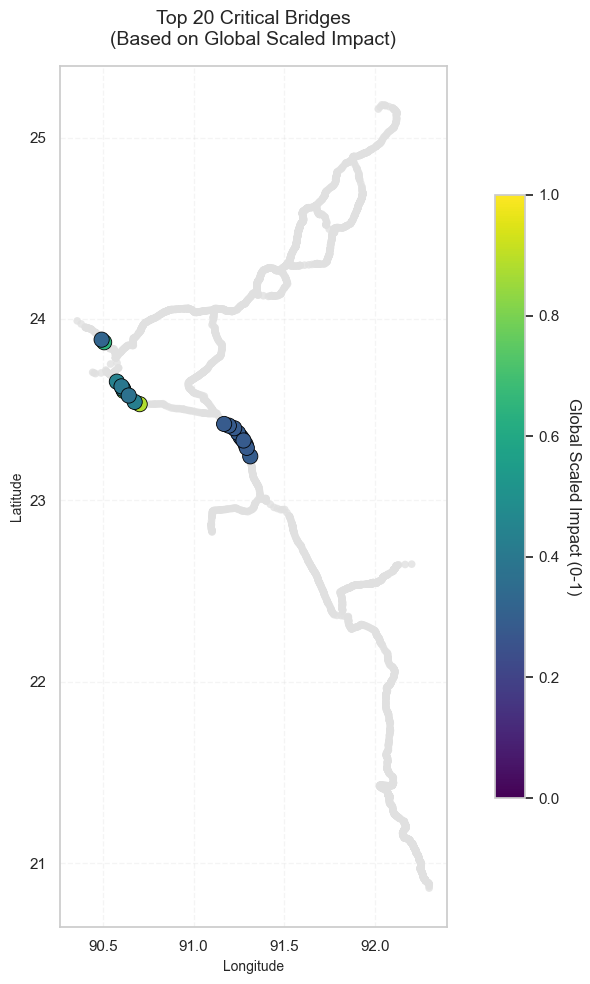

In [22]:
import matplotlib.pyplot as plt

top_20_df = avg_impact_per_bridge.head(20).copy().reset_index()

fig, ax = plt.subplots(figsize=(10, 10))

#layer1
ax.scatter(base_df['lon'], base_df['lat'],
           color='#e0e0e0',
           s=30,
           alpha=0.8,
           edgecolor='none',
           zorder=1)

#layer2 most critical bridges
sc = ax.scatter(top_20_df['lon'], top_20_df['lat'],
                c=top_20_df['impact_scaled'],
                cmap='viridis',
                s=120,
                alpha=1.0,
                edgecolor='black',
                linewidth=0.6,
                zorder=2)


#Styling & Labels
ax.set_title("Top 20 Critical Bridges\n(Based on Global Scaled Impact)", fontsize=14, pad=15)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)

ax.set_aspect('equal', adjustable='box')

ax.grid(True, linestyle='--', alpha=0.2)

#colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Global Scaled Impact (0-1)', rotation=270, labelpad=15)
sc.set_clim(0, 1) # Forceert de kleurenbalk om de volledige schaal te tonen

plt.tight_layout()

plt.savefig('../img/broken_bridges_map.png', dpi=300, bbox_inches='tight')

plt.show()

In [17]:
totaal_scenarios = 12
avg_impact_per_bridge['expected_impact'] = (
    avg_impact_per_bridge['impact_scaled'] * (avg_impact_per_bridge['occurrence_count'] / totaal_scenarios)
)

top_20_expected = avg_impact_per_bridge.sort_values(by='expected_impact', ascending=False).head(20).copy()


display_cols = ['impact_scaled', 'occurrence_count', 'expected_impact', 'lat', 'lon']
top_20_expected[display_cols].reset_index()

,id,impact_scaled,occurrence_count,expected_impact,lat,lon
0,100083,0.879217,12,0.879217,23.530384,90.702440
1,100047,0.829622,12,0.829622,23.617641,90.609551
2,100051,0.783681,12,0.783681,23.602760,90.615532
3,101484,0.647530,11,0.593569,23.871651,90.506546
4,100031,0.442117,12,0.442117,23.654426,90.576730
5,100075,0.422411,12,0.422411,23.542685,90.674829
6,100043,0.397597,12,0.397597,23.628467,90.602302
7,100059,0.371042,12,0.371042,23.577980,90.641919
8,100049,0.401661,11,0.368189,23.613587,90.610903
9,101490,0.322376,12,0.322376,23.885891,90.492776


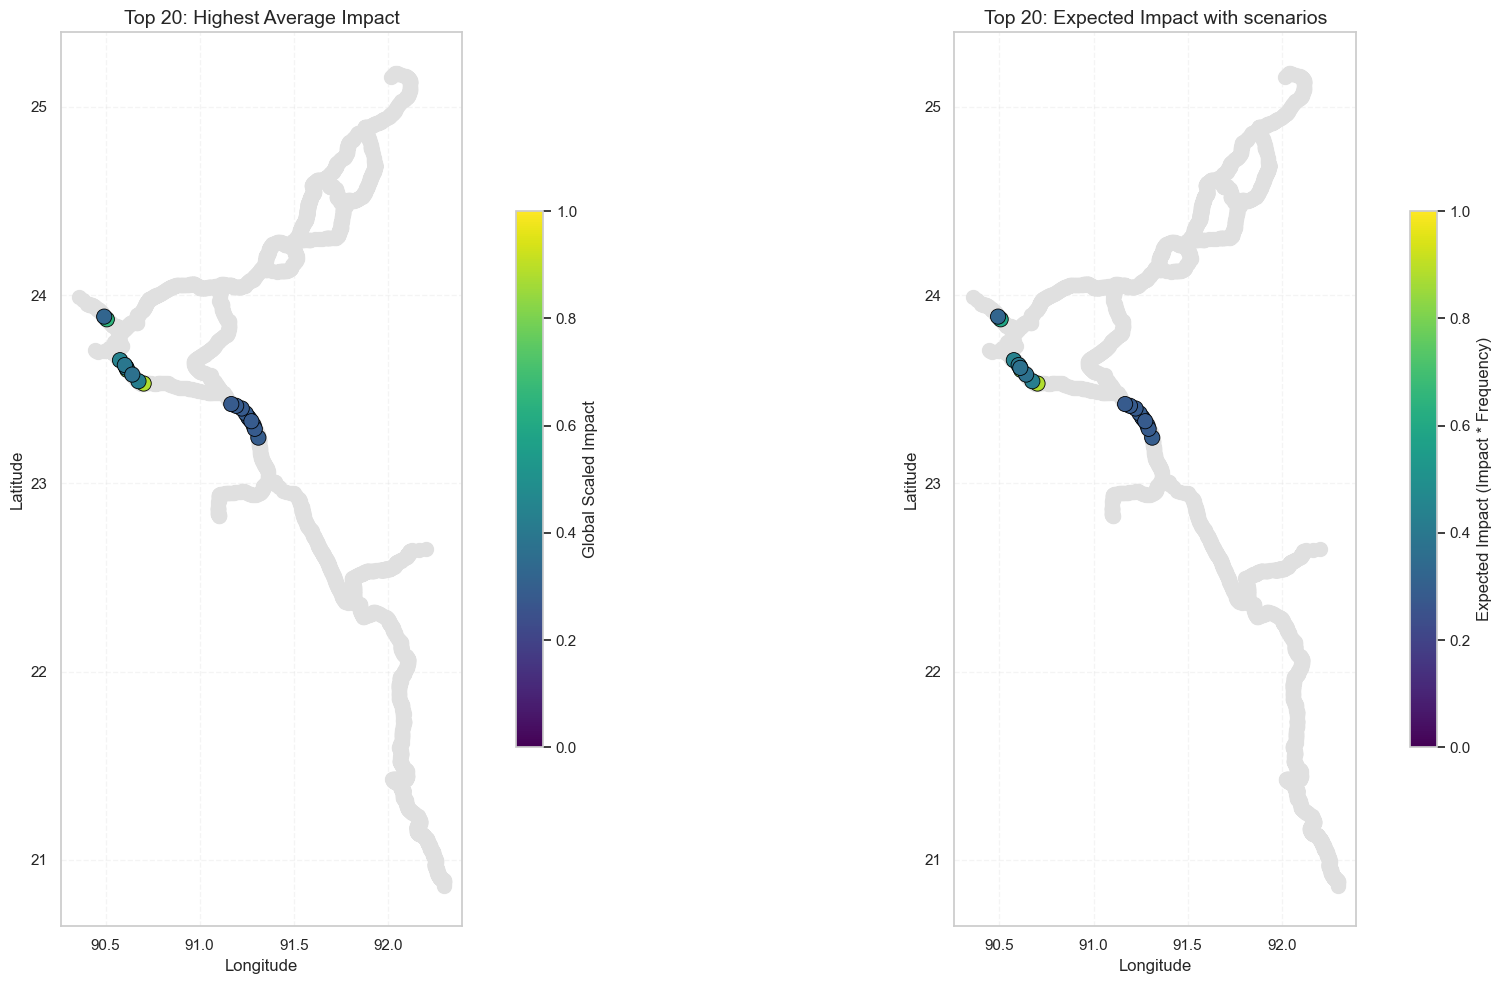

In [18]:
import matplotlib.pyplot as plt

top_20_impact = avg_impact_per_bridge.sort_values('impact_scaled', ascending=False).head(20).reset_index()

top_20_expected = avg_impact_per_bridge.sort_values('expected_impact', ascending=False).head(20).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))


ax1 = axes[0]
ax1.scatter(base_df['lon'], base_df['lat'], color= '#e0e0e0', s=100, alpha=1, zorder=1) # s verlaagd naar 2 voor context
sc1 = ax1.scatter(top_20_impact['lon'], top_20_impact['lat'],
                  c=top_20_impact['impact_scaled'], cmap='viridis',
                  s=120, alpha=1.0, edgecolor='black', linewidth=0.6, zorder=2)

ax1.set_title("Top 20: Highest Average Impact", fontsize=14)
sc1.set_clim(0, 1)
plt.colorbar(sc1, ax=ax1, shrink=0.6, label='Global Scaled Impact')

# --- RECHTER PLOT: Expected Impact (Gecorrigeerd) ---
ax2 = axes[1]
ax2.scatter(base_df['lon'], base_df['lat'], color='#e0e0e0', s=100, alpha=1, zorder=1)
sc2 = ax2.scatter(top_20_expected['lon'], top_20_expected['lat'],
                  c=top_20_expected['expected_impact'], cmap='viridis',
                  s=120, alpha=1.0, edgecolor='black', linewidth=0.6, zorder=2)

ax2.set_title("Top 20: Expected Impact with scenarios", fontsize=14)
sc2.set_clim(0, 1)
plt.colorbar(sc2, ax=ax2, shrink=0.6, label='Expected Impact (Impact * Frequency)')

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

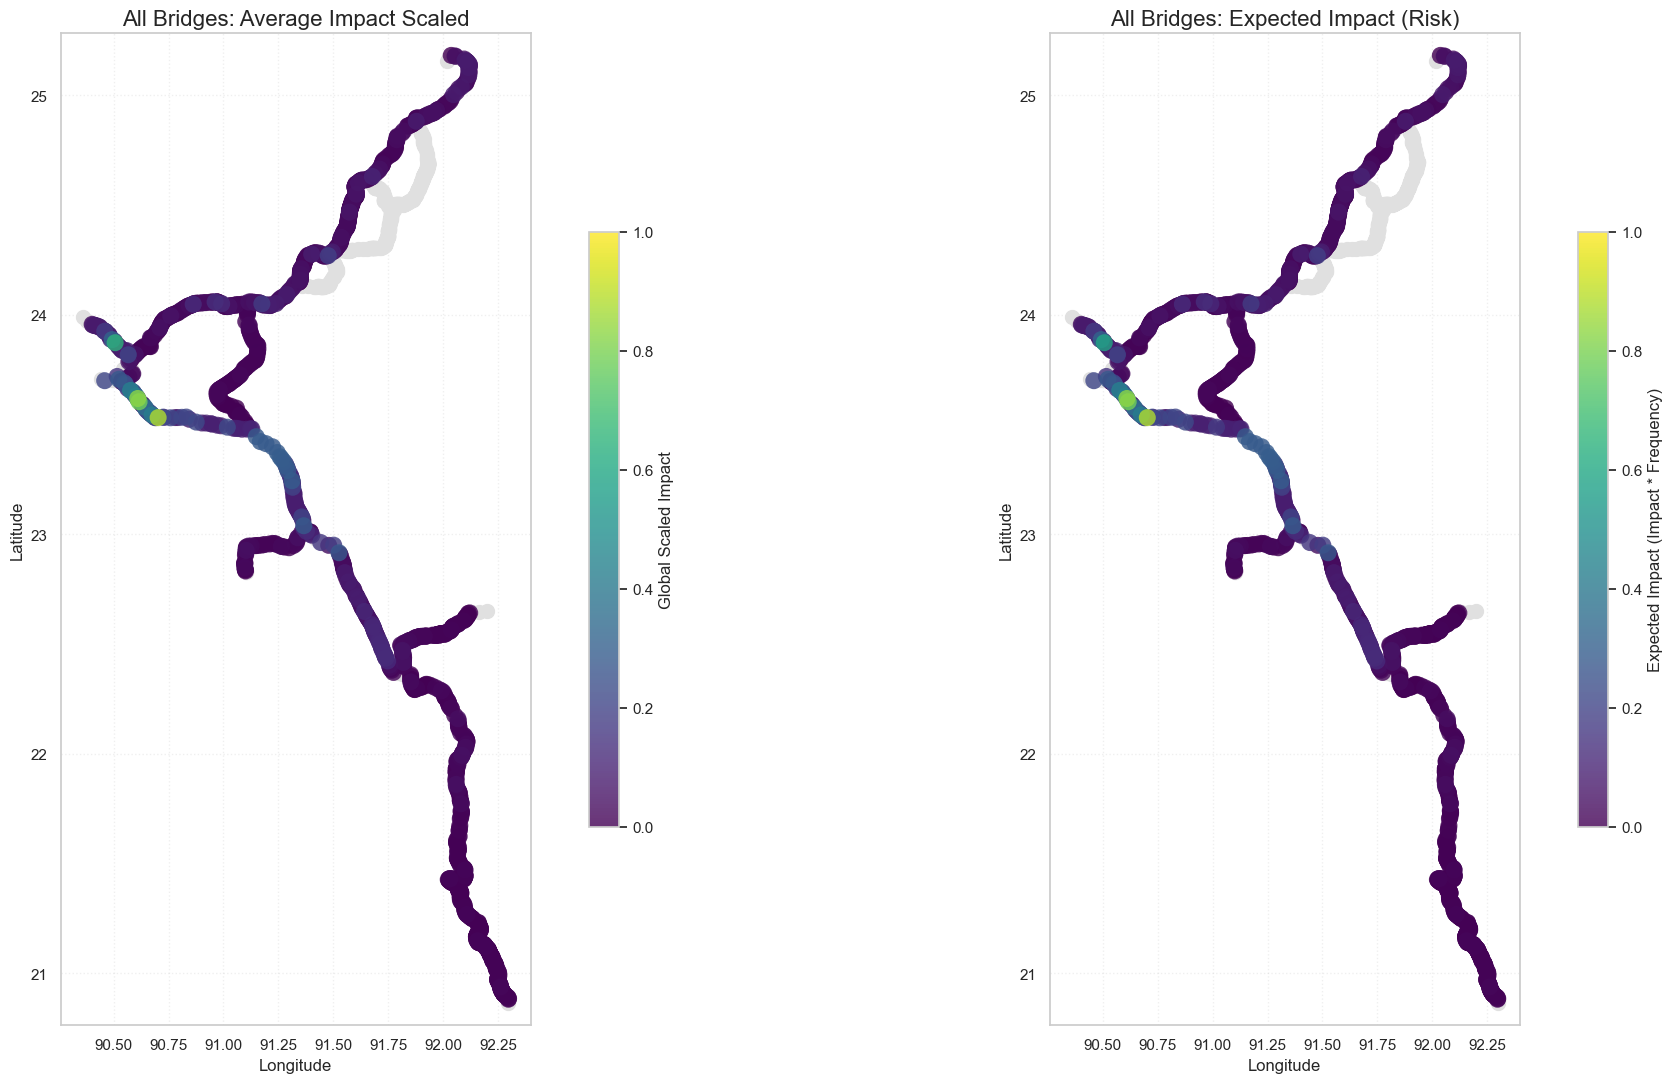

In [19]:
import matplotlib.pyplot as plt

# 1. De volledige data voorbereiden
# We sorteren op de waarde die we plotten zodat de hoogste waarden 'bovenop' liggen
all_bridges_impact = avg_impact_per_bridge.sort_values('impact_scaled', ascending=True).reset_index()
all_bridges_expected = avg_impact_per_bridge.sort_values('expected_impact', ascending=True).reset_index()

# 2. Subplots maken
fig, axes = plt.subplots(1, 2, figsize=(22, 11))

# --- LINKER PLOT: Alle Bruggen - Gemiddelde Impact ---
ax1 = axes[0]
# Wegennet op achtergrond (erg klein en licht)
ax1.scatter(base_df['lon'], base_df['lat'], color= '#e0e0e0', s=100, alpha=1, zorder=1)

# Alle bruggen
sc1 = ax1.scatter(all_bridges_impact['lon'], all_bridges_impact['lat'],
                  c=all_bridges_impact['impact_scaled'],
                  cmap='viridis',
                  s=150,          # Iets kleiner vanwege de hoeveelheid
                  alpha=0.8,
                  edgecolor='none',
                  zorder=2)

ax1.set_title("All Bridges: Average Impact Scaled", fontsize=16)
sc1.set_clim(0, 1)
plt.colorbar(sc1, ax=ax1, shrink=0.6, label='Global Scaled Impact')

# --- RECHTER PLOT: Alle Bruggen - Expected Impact ---
ax2 = axes[1]
ax2.scatter(base_df['lon'], base_df['lat'], color='#e0e0e0', s=100, alpha=1, zorder=1)

sc2 = ax2.scatter(all_bridges_expected['lon'], all_bridges_expected['lat'],
                  c=all_bridges_expected['expected_impact'],
                  cmap='viridis',
                  s=150,
                  alpha=0.8,
                  edgecolor='none',
                  zorder=2)

ax2.set_title("All Bridges: Expected Impact (Risk)", fontsize=16)
sc2.set_clim(0, 1)
plt.colorbar(sc2, ax=ax2, shrink=0.6, label='Expected Impact (Impact * Frequency)')

# --- STYLING ---
for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect('equal', adjustable='box')

    # Gebruik de volledige dataset voor de grenzen
    ax.set_xlim(base_df['lon'].min() - 0.1, base_df['lon'].max() + 0.1)
    ax.set_ylim(base_df['lat'].min() - 0.1, base_df['lat'].max() + 0.1)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_facecolor('white') # Zorg voor een schone witte achtergrond

plt.tight_layout()
plt.show()